In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [2]:
ct_gray = cv2.imread("data/slice_ct.png", cv2.IMREAD_GRAYSCALE)
mri_gray = cv2.imread("data/slice_mri.png", cv2.IMREAD_GRAYSCALE)

ct_rgb = cv2.cvtColor(ct_gray, cv2.COLOR_BGR2RGB)
mri_rgb = cv2.cvtColor(mri_gray, cv2.COLOR_BGR2RGB)

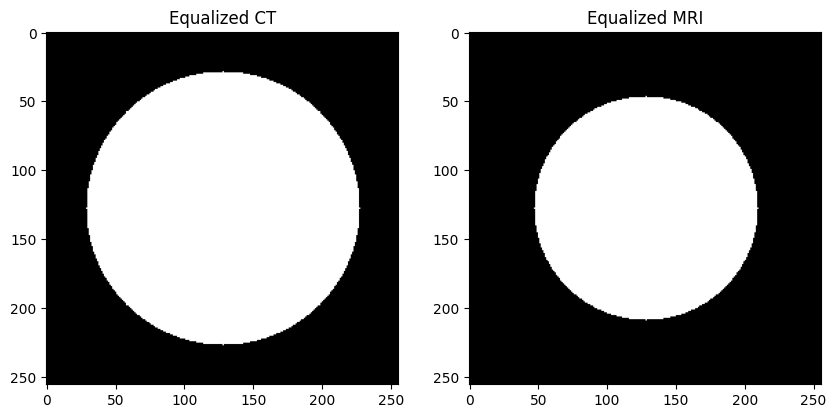

In [3]:
equalized_ct = cv2.equalizeHist(ct_gray)
equalized_mri = cv2.equalizeHist(mri_gray)

equalized_ct_rgb = cv2.cvtColor(equalized_ct, cv2.COLOR_BGR2RGB)
equalized_mri_rgb = cv2.cvtColor(equalized_mri, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(equalized_ct_rgb)
axes[0].set_title("Equalized CT")

axes[1].imshow(equalized_mri_rgb)
axes[1].set_title("Equalized MRI")

plt.show()

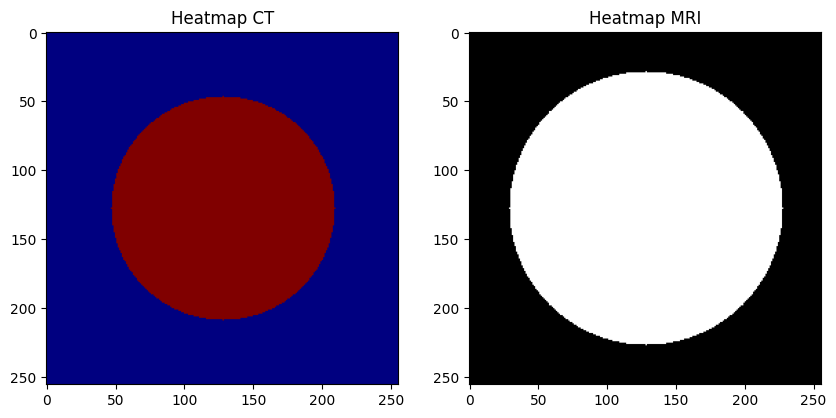

In [4]:
heatmap_ct = cv2.applyColorMap(equalized_mri, cv2.COLORMAP_JET)
heatmap_mri = cv2.applyColorMap(equalized_ct, cv2.COLORMAP_BONE)

heatmap_ct_rgb = cv2.cvtColor(heatmap_ct, cv2.COLOR_BGR2RGB)
heatmap_mri_rgb = cv2.cvtColor(heatmap_mri, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(heatmap_ct_rgb)
axes[0].set_title("Heatmap CT")

axes[1].imshow(heatmap_mri_rgb)
axes[1].set_title("Heatmap MRI")

plt.show()

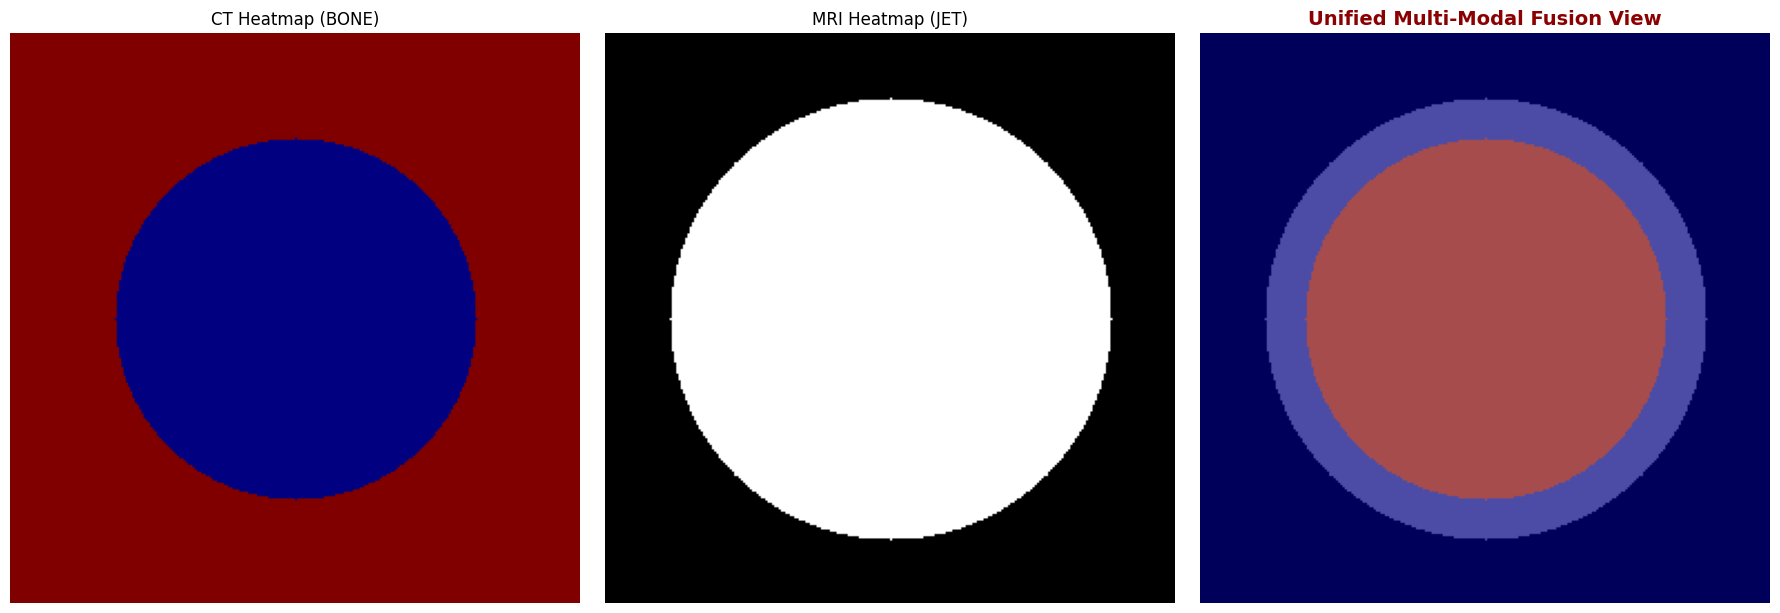

In [5]:
alpha = 0.7
beta = 0.3
fused_bgr = cv2.addWeighted(heatmap_ct, alpha, heatmap_mri, beta, 0)

fused_rgb = cv2.cvtColor(fused_bgr, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(heatmap_ct)
axes[0].set_title("CT Heatmap (BONE)", fontsize=12)
axes[0].axis("off")

axes[1].imshow(heatmap_mri)
axes[1].set_title("MRI Heatmap (JET)", fontsize=12)
axes[1].axis("off")

axes[2].imshow(fused_rgb)
axes[2].set_title(
    "Unified Multi-Modal Fusion View", fontsize=14, fontweight="bold", color="darkred"
)
axes[2].axis("off")

plt.tight_layout()
plt.show()

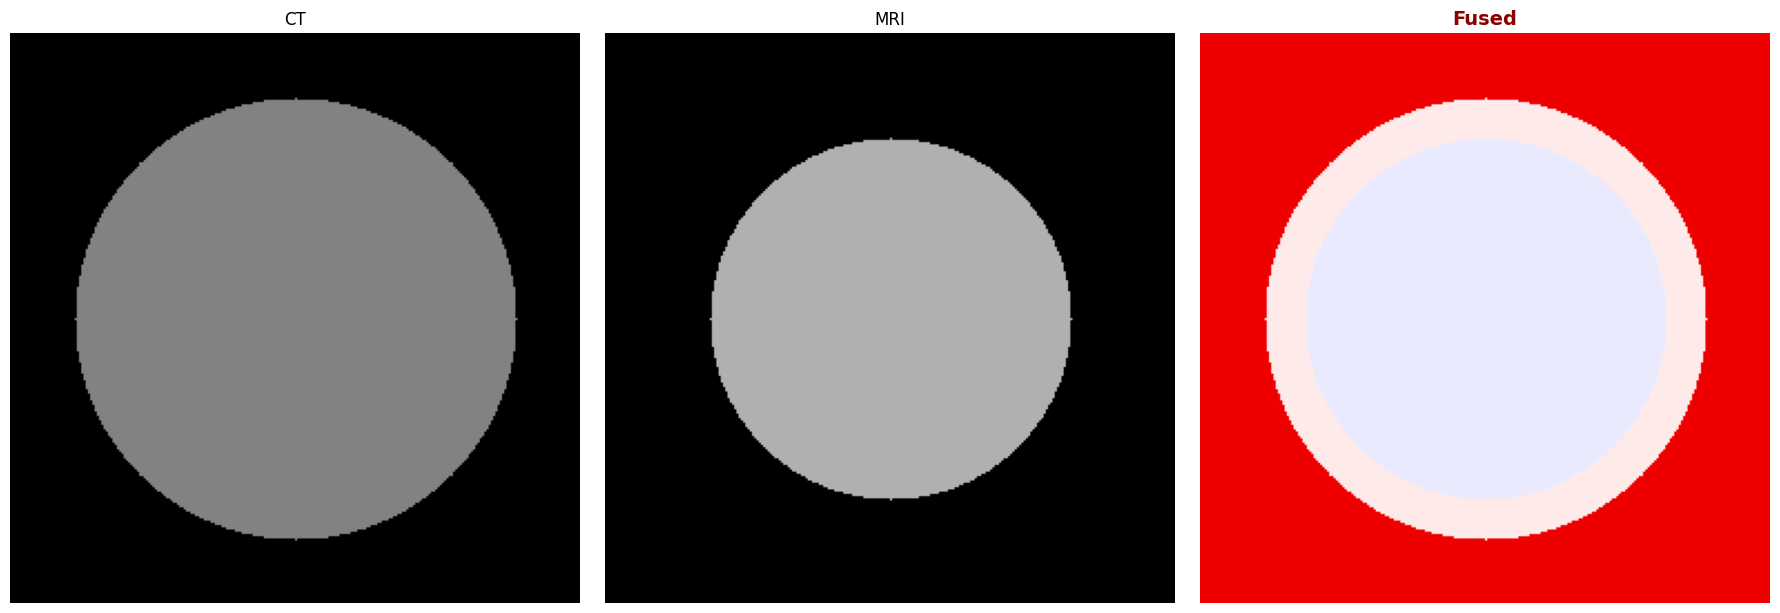

In [6]:
image_float = fused_bgr.astype(np.float32)

max_val = np.max(image_float)
c = 255 / np.log(1 + max_val)

log_transformed = c * np.log(1 + image_float)

log_transformed = np.clip(log_transformed, 0, 255).astype(np.uint8)

log_transformed_normalized = log_transformed / 255.0

gamma = 0.5

gamma_corrected = np.power(log_transformed_normalized, gamma)
gamma_corrected = (gamma_corrected * 255).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(ct_rgb)
axes[0].set_title("CT", fontsize=12)
axes[0].axis("off")

axes[1].imshow(mri_rgb)
axes[1].set_title("MRI", fontsize=12)
axes[1].axis("off")

axes[2].imshow(gamma_corrected)
axes[2].set_title(
    "Fused", fontsize=14, fontweight="bold", color="darkred"
)
axes[2].axis("off")

plt.tight_layout()
plt.show()